# Лабораторная работа № 2

## Библиотеки

In [1]:
import sys, os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

## Инициализация

In [2]:
seed = 2  # для репродуктивности
np.random.seed(seed)

In [3]:
env = gym.make("Taxi-v3", render_mode="ansi")
env.reset(seed=seed)  # изначальное состояние
print(env.render())
n_states = env.observation_space.n
n_actions = env.action_space.n
print(f"n_states={n_states}, n_actions={n_actions}")

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


n_states=500, n_actions=6


## Стохастическая политика

Политика в данном случае - это массив SxA, где S - кол-во состояний, A - кол-во действий. Его элементы - вероятность каждого действия в состоянии. Так как по заданию используется равномерное распределение, то вероятность каждого действия одинакова: 1/A

In [4]:
def initialize_policy(n_states, n_actions):
    return np.full((n_states, n_actions), 1/n_actions, dtype=np.float64)

In [5]:
policy = initialize_policy(n_states, n_actions)

In [6]:
assert type(policy) in (np.ndarray, np.matrix)  # проверка типа, он должен быть массивом или матрицей numpy

In [7]:
assert np.allclose(policy, 1./n_actions)  # проверка, что распределение равномерное

In [8]:
assert np.allclose(np.sum(policy, axis=1), 1)  # проверка, что сумма вероятностей равна 1

## Игра с моделью

In [9]:
def generate_session(env, policy, t_max=10**4):
    states, actions = [], []
    total_reward = 0.0

    state = env.reset(seed=seed)[0]  # изначальное состояние

    for t in range(t_max):  # играть до конца или до максимума тиков
        action = np.random.choice(np.arange(n_actions), p=policy[state])  # выбор действия в зависимости от политики
        new_state, reward, terminated, truncated, info = env.step(action)

        states.append(state)  # сохраняем состояние
        actions.append(action)  # сохраняем действие
        total_reward += reward  # увеличиваем вознаграждение
        state = new_state  # изменение состояния

        if terminated or truncated:  # если дошли до конца, то завершаем
            break

    return states, actions, total_reward        

In [10]:
states, actions, total_reward = generate_session(env, policy)

In [11]:
assert type(states) == type(actions) == list  # проверка типов, они должны быть списками

In [12]:
assert len(states) == len(actions)  # проверка размеров списка состояний и действий, они должны совпадать

In [13]:
assert type(total_reward) in [float, np.float64]  # проверка типа значения вознаграждения, это число с плавающей запятой

### Визуализация начального распределения вознаграждения

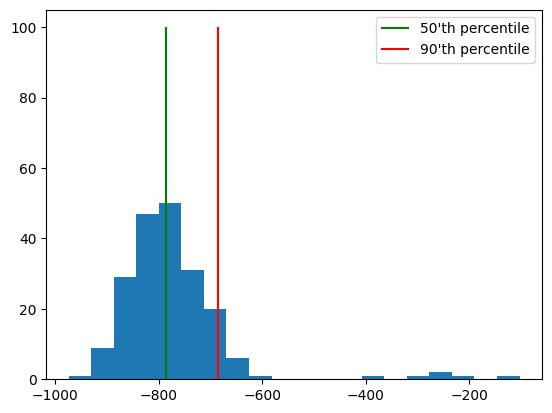

In [14]:
sample_rewards = [generate_session(env, policy, t_max=1000)[-1] for _ in range(200)]
plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="50'th percentile", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90'th percentile", color='red')
plt.legend()
plt.show()

## Шаги кросс-энтропийного метода

### Выбор состояний и действий из игры

Выбираются те состояние, которые имеют награды не меньше, чем процентиль

На вход подаются:

- *states_batch* - список списков состояний сессий
- *actions_batch* - список списков действий сессий
- *rewards_batch* - список наград сессий

На выходе получаются два списка: первый содержит сессии, а второй - соответствующие действия лучших сессий 

In [15]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    

_IncompleteInputError: incomplete input (30051502.py, line 2)